### **Automobile Dataset - Exploratory Dataset Analysis (EDA)**

This notebook demonstrates a clean, reproducible EDA workflow using Pandas and Seaborn.

**Steps Covered**
- Loads dataset and treat "?" as missing
- Data cleaning (drop columns, duplicates, missing rows)
- Correct numeric columns stored as text
- Exploratory analysis and visualisation

In [27]:
# Import libraries

from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Configuration Rules
These are project rules based on assignment instructions and dataset inspection.

In [28]:
DROP_COLS = ["normalized-losses", "symboling"]

NUMERIC_OBJECT_COLS = {
    "bore": "Float64",
    "stroke": "Float64",
    "horsepower": "Int64",
    "peak-rpm": "Int64",
    "price": "Int64",
}

## Utility Functions
Reusable helpers for loading, cleaning, and plotting.

In [29]:
def load_data(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")
    return pd.read_csv(path, na_values=["?"])


def log_shape(df: pd.DataFrame, label: str):
    print(f"{label}: rows={df.shape[0]} | cols={df.shape[1]}")


def convert_numeric_objects(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, dtype in NUMERIC_OBJECT_COLS.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(dtype)
    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(columns=DROP_COLS, errors="ignore")
    df = df.drop_duplicates()
    df = convert_numeric_objects(df)
    df = df.dropna()
    return df


def barplot_counts(series, title, xlabel, ylabel, rotation=45):
    plt.figure(figsize=(9,5))
    ax = sns.barplot(x=series.index, y=series.values)
    plt.title(title, weight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    for p in ax.patches:
        ax.annotate(int(p.get_height()),
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


def scatter_plot(df, x, y, hue, title):
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x=x, y=y, hue=hue, style=hue)
    plt.title(title, weight="bold")
    plt.tight_layout()
    plt.show()


def filter_body_style(df, style):
    return df[df["body-style"].astype(str).str.lower() == style.lower()]

## Load and Clean Dataset

In [30]:
raw_df = load_data("automobile.txt")
log_shape(raw_df, "Raw Dataset")

df = clean_data(raw_df)
log_shape(df, "Cleaned Dataset")

df.info()
df.head()

Raw Dataset: rows=205 | cols=26
Cleaned Dataset: rows=193 | cols=24
<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    object 
 1   fuel-type          193 non-null    object 
 2   aspiration         193 non-null    object 
 3   num-of-doors       193 non-null    object 
 4   body-style         193 non-null    object 
 5   drive-wheels       193 non-null    object 
 6   engine-location    193 non-null    object 
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    object 
 13  num-of-cylinders   193 non-null    object 
 14  engine-size        193 non-null    int64  
 15  fuel-system

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


## Hatchbacks and Body Style Distribution

Hatchback rows: 63


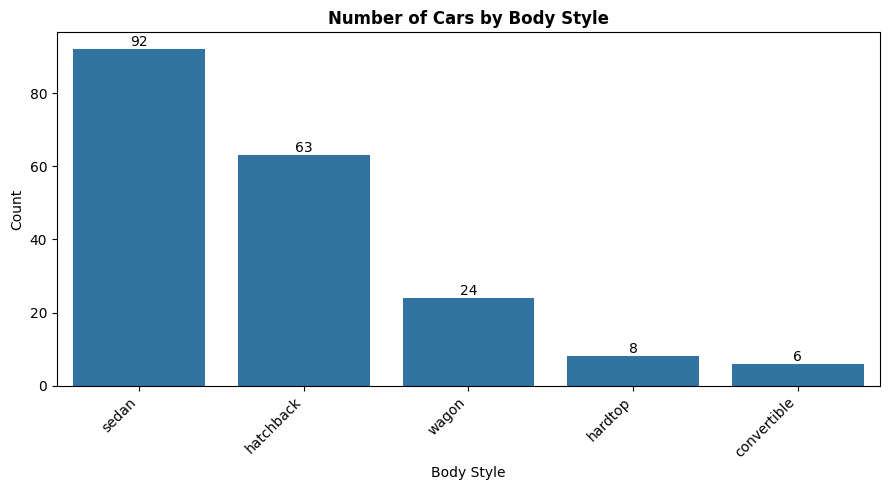

In [31]:


hatchbacks = filter_body_style(df, "hatchback")
print("Hatchback rows:", len(hatchbacks))
hatchbacks.head()

body_counts = df["body-style"].value_counts()
barplot_counts(body_counts, "Number of Cars by Body Style", "Body Style", "Count")



**Insight:**  
The dataset is dominated by sedan and hatchback body styles, indicating that compact and mid-size vehicles form the majority of entries.  
Less frequent styles such as convertibles and wagons appear sparsely, suggesting limited representation of luxury or niche vehicle segments.




## Most Expensive vs Cheapest Cars

In [32]:
# Identify price extremes to compare performance vs efficiency

top5 = df.sort_values("price", ascending=False).head(5).copy()
bottom5 = df.sort_values("price", ascending=True).head(5).copy()

top5["Category"] = "Most Expensive"
bottom5["Category"] = "Cheapest"

compare = pd.concat([top5, bottom5], ignore_index=True)
compare["Label"] = compare["make"].astype(str) + " (" + compare["body-style"].astype(str) + ")"

# Table output
compare[["make", "body-style", "price", "city-mpg", "engine-size", "Category"]]

,make,body-style,price,city-mpg,engine-size,Category
0,mercedes-benz,hardtop,45400,14,304,Most Expensive
1,bmw,sedan,41315,16,209,Most Expensive
2,mercedes-benz,sedan,40960,14,308,Most Expensive
3,porsche,convertible,37028,17,194,Most Expensive
4,bmw,sedan,36880,15,209,Most Expensive
5,subaru,hatchback,5118,31,97,Cheapest
6,chevrolet,hatchback,5151,47,61,Cheapest
7,mazda,hatchback,5195,30,91,Cheapest
8,toyota,hatchback,5348,35,92,Cheapest
9,mitsubishi,hatchback,5389,37,92,Cheapest


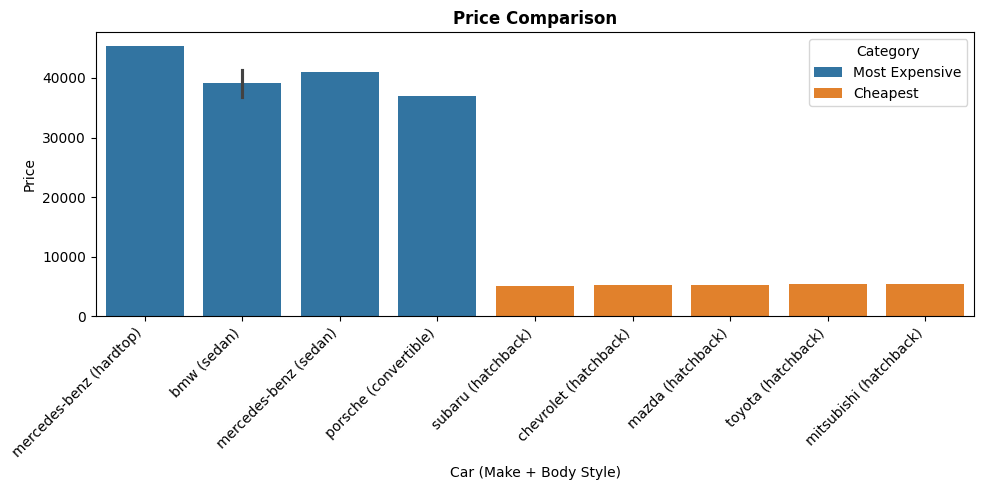

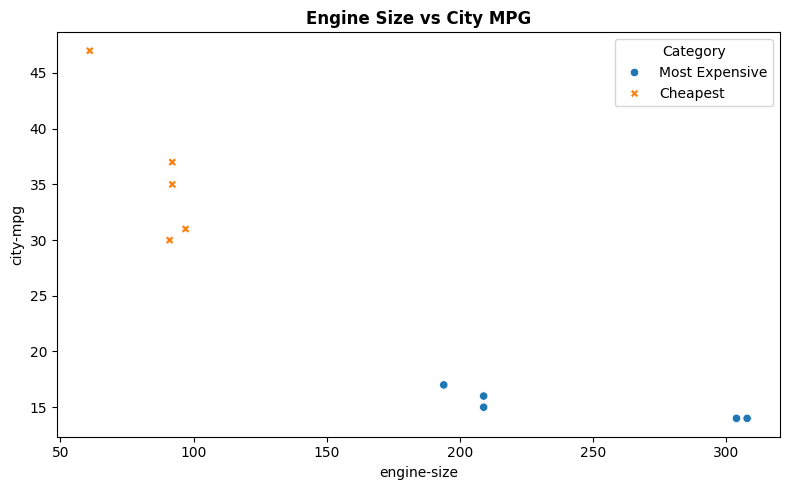

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(data=compare, x="Label", y="price", hue="Category")

plt.title("Price Comparison", weight="bold")
plt.xlabel("Car (Make + Body Style)")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

scatter_plot(compare, "engine-size", "city-mpg", "Category",
             "Engine Size vs City MPG")

## Insight:
The visuals show a strong price gap between luxury and economy vehicles. There is also a clear inverse relationship between engine size and fuel efficiency, where larger engines correspond to lower city MPG.
This reflects the common trade-off between performance and efficiency in vehicle design.

## Manufacturer Fuel Efficiency
Average MPG is calculated from city and highway values to compare overall efficiency across manufacturers.

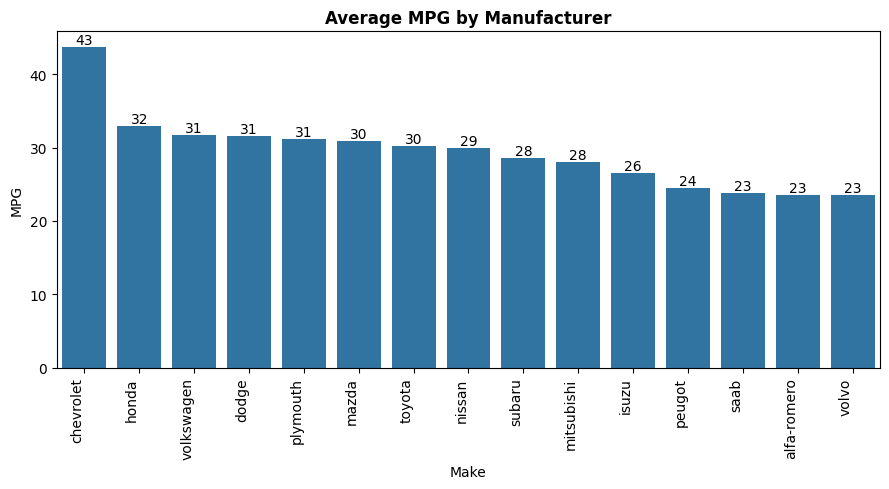

In [34]:
# Calculate average fuel efficiency metric

df["avg-mpg"] = (df["city-mpg"] + df["highway-mpg"]) / 2
fuel_eff = df.groupby("make")["avg-mpg"].mean().sort_values(ascending=False)

fuel_eff.head(10)
barplot_counts(fuel_eff.head(15), "Average MPG by Manufacturer", "Make", "MPG", rotation=90)

# Insight
Average fuel efficiency varies noticeably between manufacturers, with a small group achieving higher MPG values than the rest. This suggests differing design priorities, where some brands emphasise economy while others focus more on performance or larger engines.


## Largest Engine Capacity

In [35]:
largest_engines = df.sort_values("engine-size", ascending=False)[
    ["make","body-style","engine-size","price"]
].head(10)

largest_engines

,make,body-style,engine-size,price
49,jaguar,sedan,326,36000
73,mercedes-benz,sedan,308,40960
74,mercedes-benz,hardtop,304,45400
47,jaguar,sedan,258,32250
48,jaguar,sedan,258,35550
71,mercedes-benz,sedan,234,34184
72,mercedes-benz,convertible,234,35056
17,bmw,sedan,209,36880
16,bmw,sedan,209,41315
15,bmw,sedan,209,30760


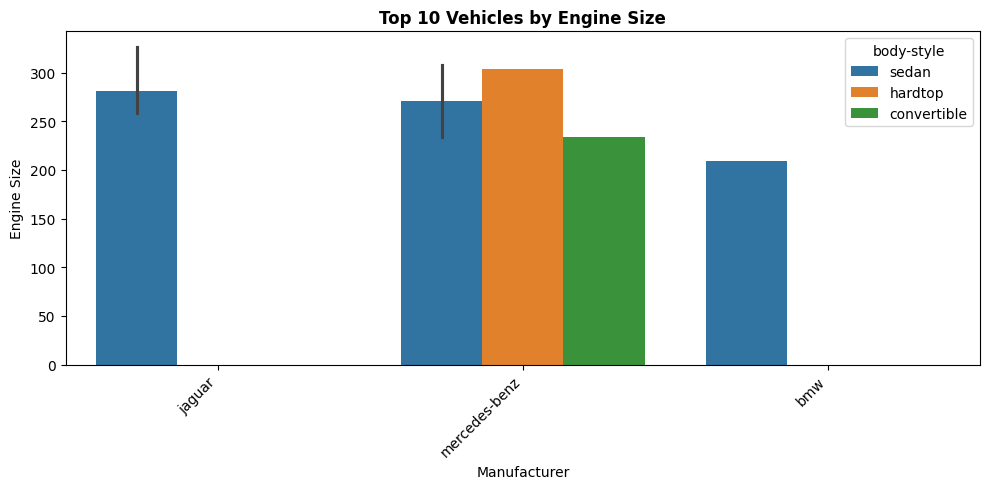

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=largest_engines,
    x="make",
    y="engine-size",
    hue="body-style"
)

plt.title("Top 10 Vehicles by Engine Size", weight="bold")
plt.xlabel("Manufacturer")
plt.ylabel("Engine Size")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Insight:
The largest engine sizes are concentrated among a small number of manufacturers, with Jaguar, Mercedes-Benz, and BMW appearing multiple times in the top rankings. This pattern suggests a stronger emphasis on performance-oriented vehicle design rather than fuel efficiency

## Manufacturer with Most Models

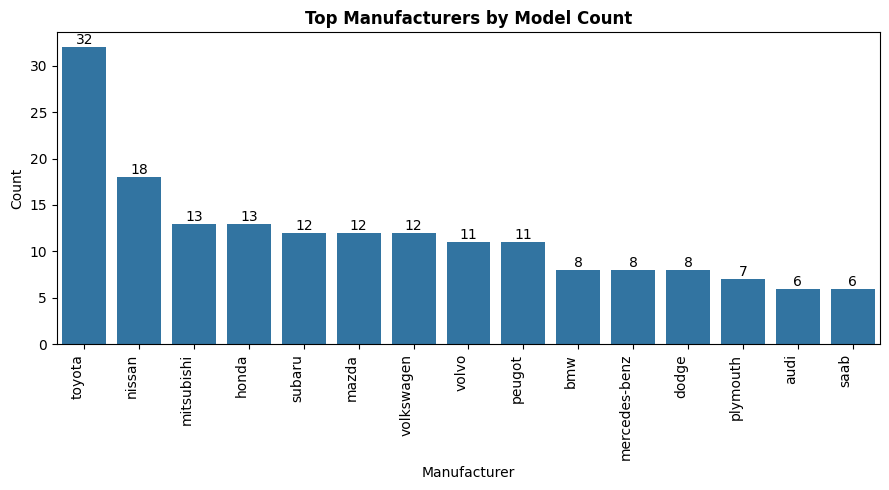

In [37]:
model_counts = df["make"].value_counts()
model_counts.head(10)

barplot_counts(model_counts.head(15),
               "Top Manufacturers by Model Count",
               "Manufacturer",
               "Count",
               rotation=90)

## Insight
Toyota has the highest number of models in the dataset, indicating a broader product portfolio compared to other manufacturers. The sharp decline after the leading brand suggests that most competitors offer a more limited range of vehicle models.

## Summary
- Sedan and hatchback vehicles dominate the dataset.
- Larger engine sizes are generally associated with lower fuel efficiency.
- Fuel economy varies across manufacturers, indicating differing design priorities.
- Toyota is the manufacturer with the highest number car models.
- A small number of manufacturers contribute the majority of vehicle models.
